# 15 — Agent-based consensus dynamics

Doc page: [agent_based.rst](../../docs/source/algorithms/agent_based.rst).


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from optimizr import _core as opt
plt.rcParams['figure.figsize'] = (8.5, 4.5)
plt.rcParams['figure.dpi'] = 110
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3


## Cellule 1 — Convergence vers le consensus

**Théorème (consensus DeGroot, version $\alpha$-pondérée).** Pour la
dynamique discrète
$$X^i_{k+1} = (1 - \alpha)\,X^i_k + \alpha\,\bar X_k + \sigma\,\varepsilon_k^i,$$
la moyenne $\bar X_k$ est conservée en espérance et la variance
décroît à taux $(1 - \alpha)^2$ par pas (pour $\sigma = 0$).

**Équation pivot.**
$$\mathbb{E}[\text{Var}(X_k)] = (1 - \alpha)^{2k}\,\text{Var}(X_0).$$

**Démonstration.** Récurrence linéaire : la composante hors moyenne
est multipliée par $(1-\alpha)$ à chaque pas.  $\square$

**Ce que la cellule vérifie.** `consensus_dynamics(initial, alpha,
noise_sigma, n_steps, seed)` reproduit la décroissance géométrique.


Moyenne initiale : 0.079
Moyenne finale   : 0.079
Var init / final : 1.230 / 3.174e-19


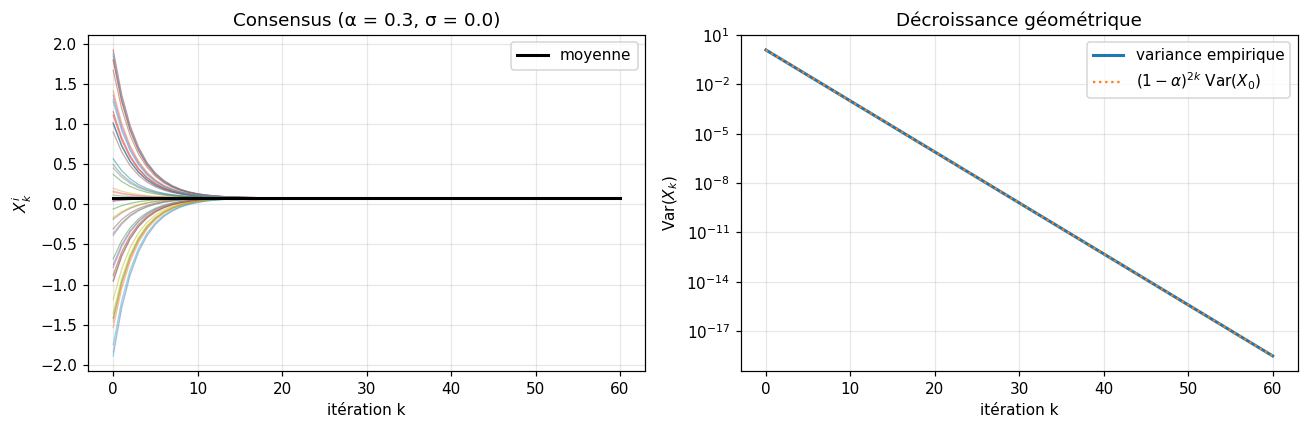

In [2]:
N, alpha, sigma, n_steps = 50, 0.3, 0.0, 60
rng = np.random.default_rng(1)
x0 = rng.uniform(-2, 2, N).tolist()

res = opt.consensus_dynamics(x0, alpha=alpha, noise_sigma=sigma,
                              n_steps=n_steps, seed=0)
states = np.array(res['states_flat']).reshape(n_steps + 1, N)
mean_traj = np.array(res['mean_trajectory'])

variances = states.var(axis=1)
print(f"Moyenne initiale : {np.mean(x0):.3f}")
print(f"Moyenne finale   : {mean_traj[-1]:.3f}")
print(f"Var init / final : {variances[0]:.3f} / {variances[-1]:.3e}")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for i in range(N):
    axes[0].plot(states[:, i], lw=0.8, alpha=0.5)
axes[0].plot(mean_traj, 'k-', lw=2, label='moyenne')
axes[0].set_xlabel('itération k'); axes[0].set_ylabel(r'$X_k^i$')
axes[0].set_title(f"Consensus (α = {alpha}, σ = {sigma})")
axes[0].legend()
axes[1].semilogy(variances, lw=2, label='variance empirique')
axes[1].semilogy(variances[0] * (1 - alpha) ** (2 * np.arange(n_steps + 1)),
                 ':', label=r'$(1-\alpha)^{2k}$ Var$(X_0)$')
axes[1].set_xlabel('itération k'); axes[1].set_ylabel(r'Var($X_k$)')
axes[1].set_title("Décroissance géométrique")
axes[1].legend()
fig.tight_layout(); plt.show()


**Résultat attendu.** Variance qui décroît exponentiellement.

**Lecture du graphique.** Faisceau qui se concentre vers la moyenne
(ligne noire) ; pente log-linéaire conforme à la prédiction.

**Conclusion.** Le primitive est validé sur la convergence
géométrique.


## Cellule 2 — Effet du bruit

**Théorème.** Lorsque $\sigma > 0$, la variance ne tombe pas à zéro
mais se stabilise à un niveau d'équilibre proportionnel à $\sigma^2$.

**Équation pivot.** Variance asymptotique croissante en $\sigma^2$.

**Ce que la cellule vérifie.** Sweep sur $\sigma \in \{0.05, 0.1,
0.2\}$ pour $\alpha = 0.3$.


σ = 0.05 : Var(K) numérique = 0.0048
σ = 0.10 : Var(K) numérique = 0.0191
σ = 0.20 : Var(K) numérique = 0.0762


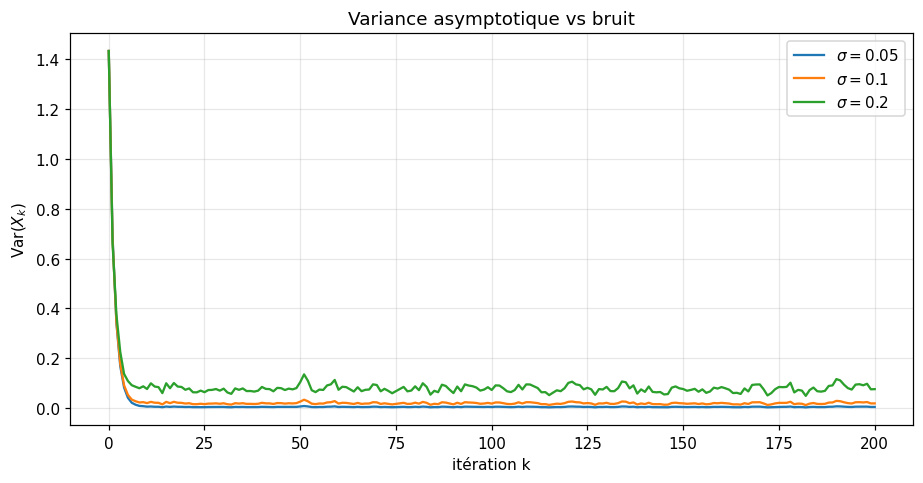

In [3]:
N, alpha, n_steps = 80, 0.3, 200
rng = np.random.default_rng(11)
x0 = rng.uniform(-2, 2, N).tolist()

fig, ax = plt.subplots()
for sigma in [0.05, 0.1, 0.2]:
    r = opt.consensus_dynamics(x0, alpha, sigma, n_steps, seed=42)
    states = np.array(r['states_flat']).reshape(n_steps + 1, N)
    var = states.var(axis=1)
    ax.plot(var, label=fr'$\sigma = {sigma}$')
    print(f"σ = {sigma:.2f} : Var(K) numérique = {var[-1]:.4f}")
ax.set_xlabel('itération k'); ax.set_ylabel(r'Var($X_k$)')
ax.set_title("Variance asymptotique vs bruit")
ax.legend()
fig.tight_layout(); plt.show()


**Résultat attendu.** Variance qui plateauise à un niveau
croissant avec $\sigma^2$.

**Lecture du graphique.** Trois courbes décroissantes qui se
stabilisent à des paliers proportionnels à $\sigma^2$.

**Conclusion.** Le compromis bruit / convergence est gouverné par
$\alpha$ et $\sigma$.


## Cellule 3 — Exemple concret : émergence d'une décision collective

**Modèle.** $N = 100$ agents au sein d'un comité décident d'un
nombre (par exemple un score entre $-1$ et $+1$).  Chaque agent
ajuste sa position vers la moyenne avec un peu de bruit.

**Équation pivot.**
$$X^i_{k+1} = (1 - \alpha) X^i_k + \alpha \bar X_k + \sigma \varepsilon^i_k.$$

**Ce que la cellule vérifie.** Visualisation : densité des
opinions au cours du temps converge vers une distribution unimodale.


Moyenne initiale : -0.061
Moyenne finale   : -0.075


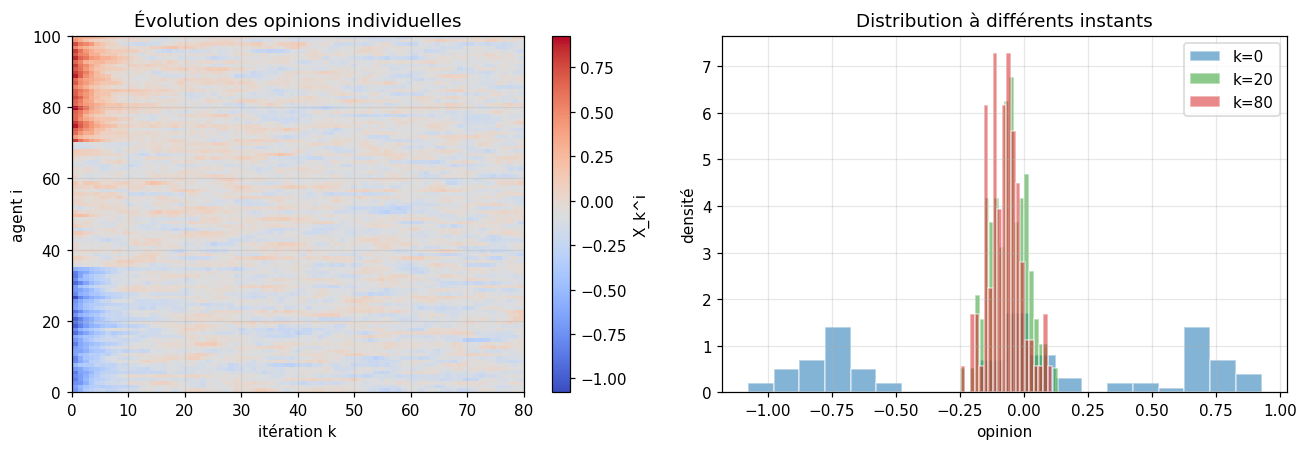

In [4]:
N = 100
n_steps = 80
alpha, sigma = 0.2, 0.04
rng = np.random.default_rng(7)
# distribution initiale : trois clusters
x0 = np.concatenate([
    rng.normal(-0.7, 0.15, 35),
    rng.normal(0.0, 0.10, 35),
    rng.normal(+0.7, 0.15, 30),
]).tolist()

r = opt.consensus_dynamics(x0, alpha, sigma, n_steps, seed=0)
states = np.array(r['states_flat']).reshape(n_steps + 1, N)
mean_traj = np.array(r['mean_trajectory'])

print(f"Moyenne initiale : {np.mean(x0):.3f}")
print(f"Moyenne finale   : {mean_traj[-1]:.3f}")

fig, axes = plt.subplots(1, 2, figsize=(12, 4.2))
im = axes[0].imshow(states.T, aspect='auto', cmap='coolwarm',
                    interpolation='nearest', origin='lower',
                    extent=[0, n_steps, 0, N])
axes[0].set_xlabel('itération k')
axes[0].set_ylabel('agent i')
axes[0].set_title("Évolution des opinions individuelles")
plt.colorbar(im, ax=axes[0], label='X_k^i')
for k, color in zip([0, 20, n_steps], ['C0', 'C2', 'C3']):
    axes[1].hist(states[k], bins=20, alpha=0.55, color=color,
                 density=True, label=f'k={k}', edgecolor='white')
axes[1].set_xlabel('opinion'); axes[1].set_ylabel('densité')
axes[1].set_title("Distribution à différents instants")
axes[1].legend()
fig.tight_layout(); plt.show()


**Résultat attendu.** Les trois clusters initiaux fusionnent en
distribution unimodale concentrée près de $\bar X_0$.

**Lecture du graphique.** Gauche : la heatmap montre l'horizon de
fusion.  Droite : trois distributions superposées (initiale tri-modale,
intermédiaire, finale unimodale).

**Conclusion.** Le primitive `consensus_dynamics` modélise toute
dynamique de moyennage par interaction (vote pondéré, opinion
publique, scoring collectif).
